In [1]:
import numpy as np
import OpenEXR
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

In [2]:
def read_exr_rgb(path):
    with OpenEXR.File(path) as exr:
        part = exr.parts[0]
        channels = part.channels
        rgb = channels["RGBA"].pixels[..., :3].astype(np.float32)
    return rgb

In [3]:
def get_blocks(img):
    blocks = []
    
    for i in range (0, 20):
        block = img[starting_y:starting_y+x_step, starting_x+(i*x_step):starting_x+(i+1)*x_step]
        blocks.append(block)

    return blocks

In [4]:
homePath = r"D:\ThesisData"

In [5]:
currentFolder = r"\front_notrees\200\600"

path = homePath + currentFolder
path

'D:\\ThesisData\\front_notrees\\200\\600'

In [1]:
# check on a single image the validity of the selected areas of interest

name = r"\Color\img_0001.exr"
img = read_exr_rgb(path + name)

plt.figure(figsize=(19.2, 10.8))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

NameError: name 'read_exr_rgb' is not defined

In [7]:
y, x, c = img.shape

x_step = x//24
starting_x = 2 * x_step

starting_y = y//2-x_step//2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0009775162..0.6381836].


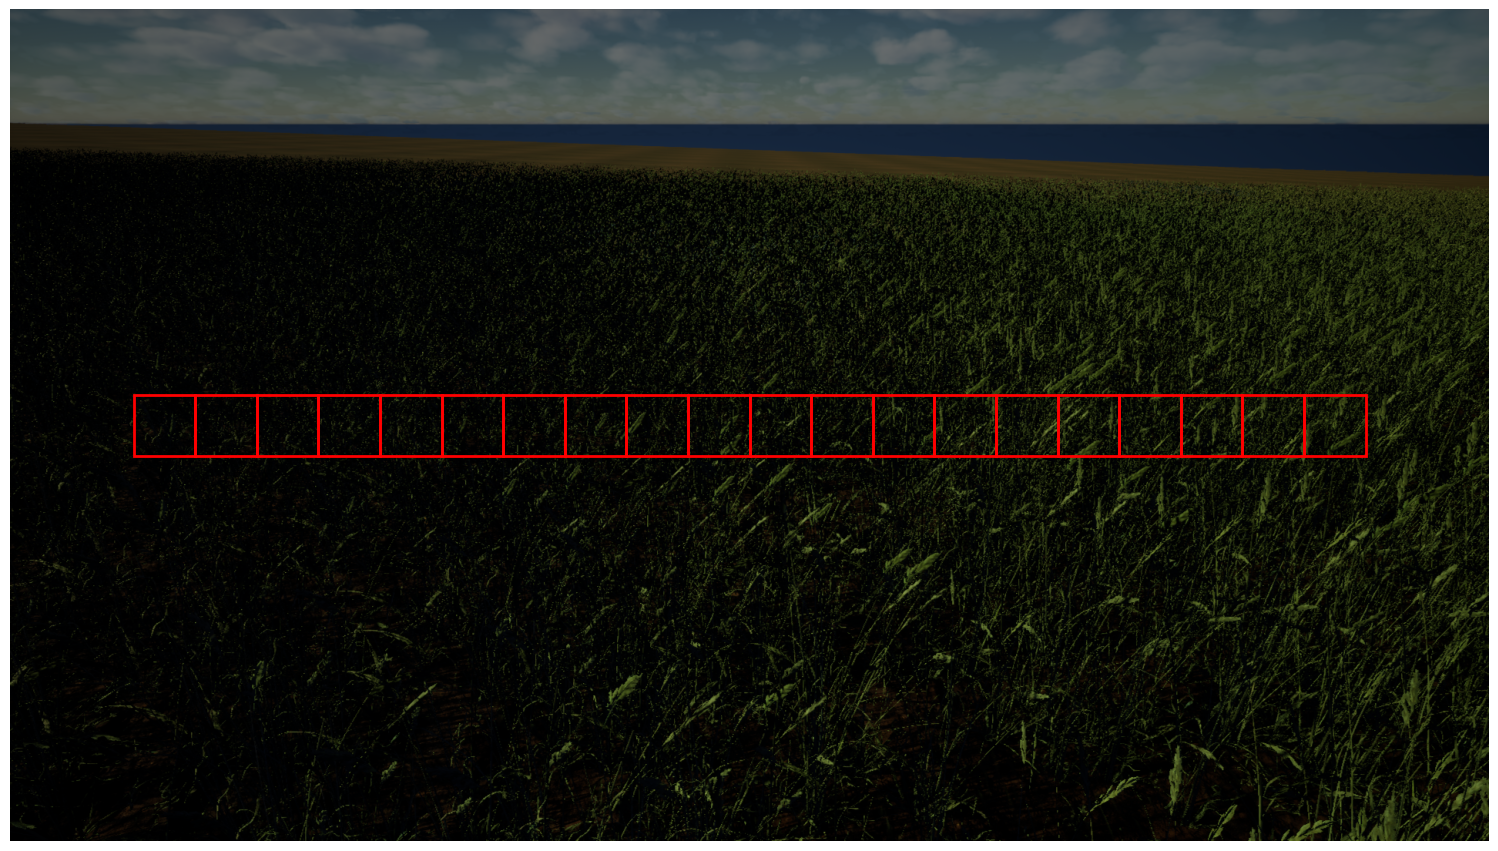

In [8]:
fig, ax = plt.subplots(figsize=(19.2, 10.8))
ax.imshow(img)

for i in range (0, 20):
    rect = patches.Rectangle(
        (starting_x + (i*x_step), starting_y),
        x_step,
        x_step,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.axis("off")
plt.show()

In [9]:
blocks = get_blocks(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1920929e-07..0.27783203].


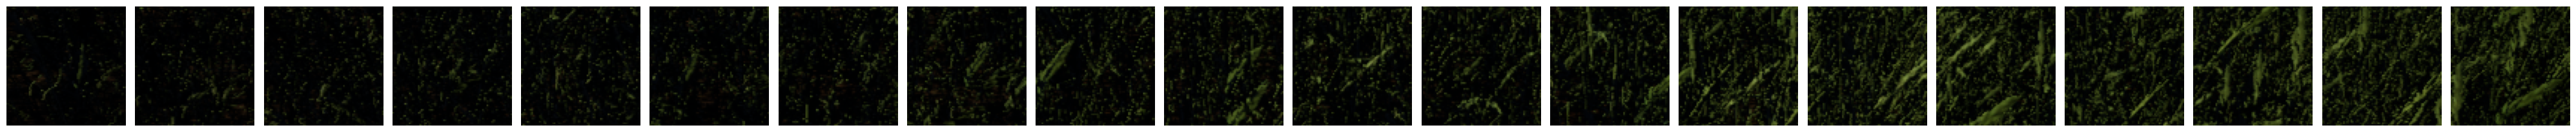

In [10]:
plt.figure(figsize=(40, 4))

for i in range (0, len(blocks)):
    plt.subplot(1, len(blocks), i+1)
    plt.axis("off")
    plt.imshow(blocks[i])

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1920929e-07..0.27783203].


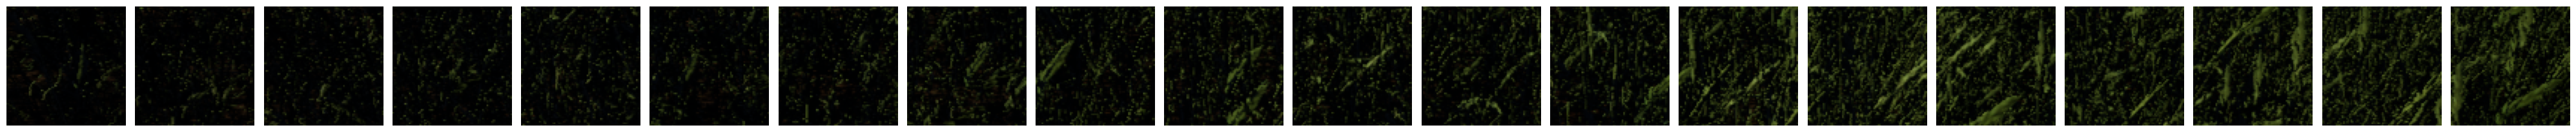

In [11]:
blocks_np = np.stack(blocks)

plt.figure(figsize=(40, 4))

for i in range (0, len(blocks_np)):
    plt.subplot(1, len(blocks_np), i+1)
    plt.axis("off")
    plt.imshow(blocks_np[i])

plt.tight_layout()
plt.show()

In [12]:
np.save(path + r"\Processed\proc_test.npy", blocks_np)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1920929e-07..0.27783203].


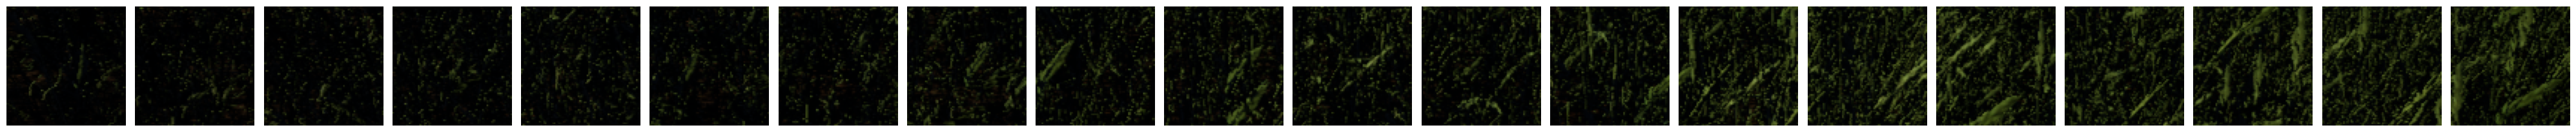

In [13]:
# validation

test = np.load(path + r"\Processed\proc_test.npy")
plt.figure(figsize=(40, 4))

for i in range (0, len(test)):
    plt.subplot(1, len(test), i+1)
    plt.axis("off")
    plt.imshow(test[i])

plt.tight_layout()
plt.show()